In [22]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

In [23]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

In [24]:
URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
data = pd.read_csv(URL1)
print(data.head())

   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
0             1  2010-06-04       Falcon 9  6104.959412   LEO  CCAFS SLC 40   
1             2  2012-05-22       Falcon 9   525.000000   LEO  CCAFS SLC 40   
2             3  2013-03-01       Falcon 9   677.000000   ISS  CCAFS SLC 40   
3             4  2013-09-29       Falcon 9   500.000000    PO   VAFB SLC 4E   
4             5  2013-12-03       Falcon 9  3170.000000   GTO  CCAFS SLC 40   

       Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  \
0    None None        1     False   False  False        NaN    1.0   
1    None None        1     False   False  False        NaN    1.0   
2    None None        1     False   False  False        NaN    1.0   
3  False Ocean        1     False   False  False        NaN    1.0   
4    None None        1     False   False  False        NaN    1.0   

   ReusedCount Serial   Longitude   Latitude  Class  
0            0  B0003  -80.577366  28.561857      

In [25]:
URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
data2 = pd.read_csv(URL2)
print(data.head())

   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
0             1  2010-06-04       Falcon 9  6104.959412   LEO  CCAFS SLC 40   
1             2  2012-05-22       Falcon 9   525.000000   LEO  CCAFS SLC 40   
2             3  2013-03-01       Falcon 9   677.000000   ISS  CCAFS SLC 40   
3             4  2013-09-29       Falcon 9   500.000000    PO   VAFB SLC 4E   
4             5  2013-12-03       Falcon 9  3170.000000   GTO  CCAFS SLC 40   

       Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  \
0    None None        1     False   False  False        NaN    1.0   
1    None None        1     False   False  False        NaN    1.0   
2    None None        1     False   False  False        NaN    1.0   
3  False Ocean        1     False   False  False        NaN    1.0   
4    None None        1     False   False  False        NaN    1.0   

   ReusedCount Serial   Longitude   Latitude  Class  
0            0  B0003  -80.577366  28.561857      

In [26]:
Y_series = data['Class']
Y = Y_series.to_numpy()
print(type(Y_series))  # <class 'pandas.core.series.Series'>
print(type(Y))         # <class 'numpy.ndarray'>
print(Y[:5])           # mostrar primeros 5 valores

<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
[0 0 0 0 0]


In [ ]:
X_numeric = X.select_dtypes(include=['int64', 'float64'])

from sklearn.preprocessing import StandardScaler

scaler = scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)
print(X[:5])

Tuned hyperparameters (best parameters): {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.7446428571428572


In [28]:
transform = preprocessing.StandardScaler()

In [29]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,          # características
    Y,          # etiqueta/objetivo
    test_size=0.2,
    random_state=2
)

In [30]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (72, 17)
X_test shape: (18, 17)
Y_train shape: (72,)
Y_test shape: (18,)


In [33]:
# Dividir X_scaled y Y en train/test
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=2
)

# Definir el modelo base
lr = LogisticRegression(max_iter=1000)

# Definir la grilla de parámetros
parameters = {
    "C": [0.01, 0.1, 1],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

# Crear GridSearchCV
logreg_cv = GridSearchCV(estimator=lr, param_grid=parameters, cv=10)

# Ajustar el modelo con los datos estandarizados
logreg_cv.fit(X_train, Y_train)

# Resultados
print("Tuned hyperparameters (best parameters):", logreg_cv.best_params_)
print("Accuracy:", logreg_cv.best_score_)


Tuned hyperparameters (best parameters): {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.7446428571428572


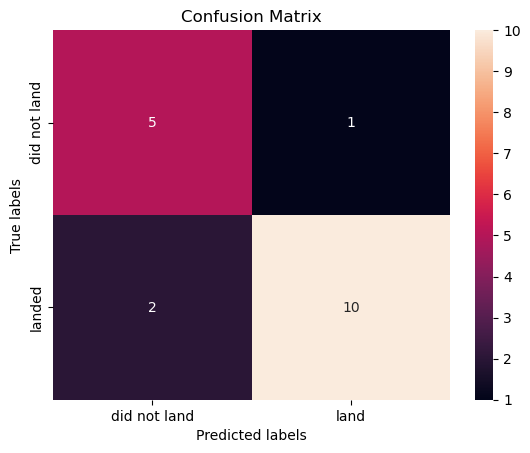

In [34]:
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [35]:
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()

In [36]:
svm_cv = GridSearchCV(estimator=svm, param_grid=parameters, cv=10)
svm_cv.fit(X_train, Y_train)


,estimator,SVC()
,param_grid,"{'C': array([1.0000...00000000e+03]), 'gamma': array([1.0000...00000000e+03]), 'kernel': ('linear', ...)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,np.float64(1000.0)


In [37]:
print("Best parameters for SVM:", svm_cv.best_params_)
print("Best cross-validation accuracy:", svm_cv.best_score_)

Best parameters for SVM: {'C': np.float64(1000.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
Best cross-validation accuracy: 0.8321428571428571


In [38]:
test_accuracy = svm_cv.score(X_test, Y_test)
print("Test set accuracy:", test_accuracy)

Test set accuracy: 0.7777777777777778


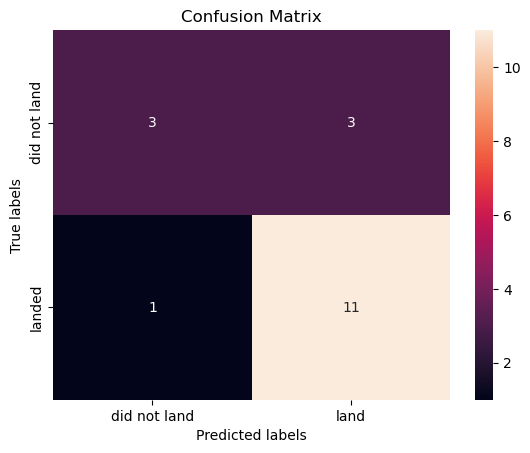

In [39]:
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [40]:
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['auto', 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()

In [41]:
tree_cv = GridSearchCV(estimator=tree, param_grid=parameters, cv=10)
tree_cv.fit(X_train, Y_train)
print("Best parameters for Decision Tree:", tree_cv.best_params_)
print("Best cross-validation accuracy:", tree_cv.best_score_)

Best parameters for Decision Tree: {'criterion': 'gini', 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'random'}
Best cross-validation accuracy: 0.8303571428571429


d:\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
3240 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3240 fits failed with the following error:
Traceback (most recent call last):
  File "d:\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\anaconda\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "d:\anaconda\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_parameter_constraints(
    ~~~~~~~~~~

In [42]:
# Calcular accuracy en el conjunto de prueba
test_accuracy_tree = tree_cv.score(X_test, Y_test)

print("Test set accuracy (Decision Tree):", test_accuracy_tree)

Test set accuracy (Decision Tree): 0.8333333333333334


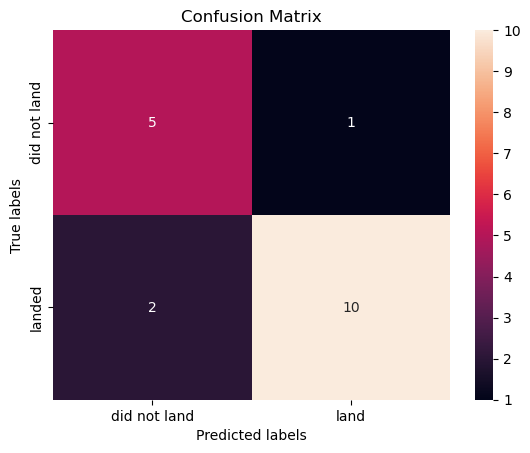

In [43]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [44]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()

In [45]:
num_registros = X_test.shape[0]
print("Número de registros en la muestra de prueba:", num_registros)

Número de registros en la muestra de prueba: 18


In [46]:
best_kernel = svm_cv.best_params_['kernel']
print("El kernel con mejor resultado en el conjunto de validación es:", best_kernel)

El kernel con mejor resultado en el conjunto de validación es: sigmoid


In [47]:
precision_test = tree_cv.score(X_test, Y_test)
print("Precisión en el conjunto de prueba del árbol de decisión:", precision_test)

Precisión en el conjunto de prueba del árbol de decisión: 0.8333333333333334
